# Kwantyzacja kolorów

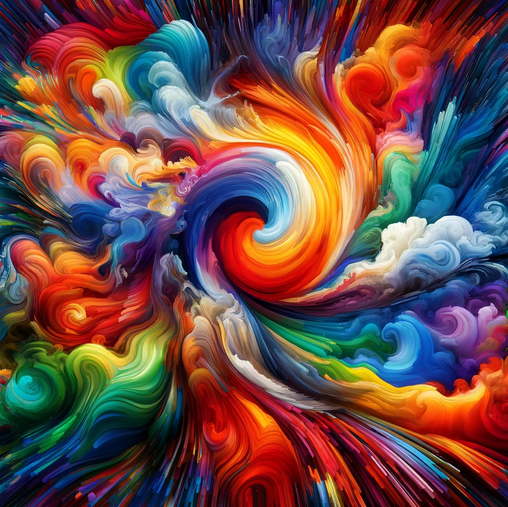

## Wstęp
Standardowy kolorowy obraz rozmiarów $n \times m$ jest reprezentowany przez $n \cdot m \cdot 3$ liczb całkowitych z przedziału $[0, 255]$. Daje to łącznie ponad 16 milionów możliwych kolorów. Kwantyzacja kolorów polega na drastycznym zredukowaniu liczby używanych kolorów w celu redukcji rozmiaru pliku, przy jednoczesnym jak najlepszym zachowaniu jakości obrazu.
Najprostszą metodą kwantyzacji jest użycie metody $k$-means. Działa znakomicie jeśli chodzi o redukcję kolorów, jednak jej natura wpływa też na ostateczny wygląd obrazka:


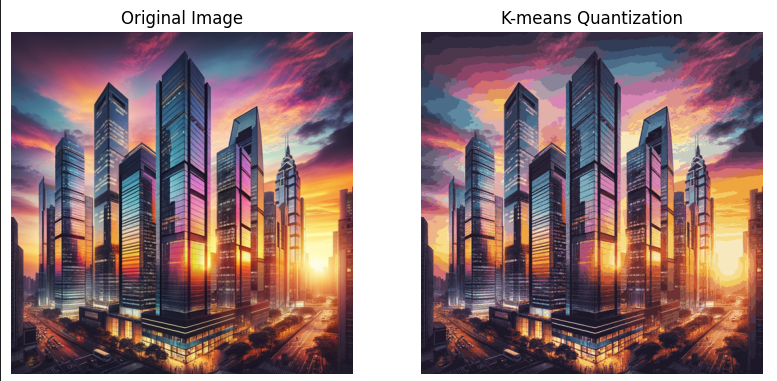


Metoda ([$k$-means](https://en.wikipedia.org/wiki/K-means_clustering)) kwantyzuje obraz minimalizując błąd średniokwadratowy ([mean squared error - MSE](https://en.wikipedia.org/wiki/Mean_squared_error)) pomiędzy oryginalnym a zrekonstruowanym obrazkiem. 
Jednakże zupełnie nie obchodzi jej jakich kolorów ostatecznie użyje. Okazuje się jednak, że jeśli narzucimy koszty użycia kolorów to będziemy w stanie wpłynąć na jakość kwantyzacji. Wtedy jednak metoda $k$-means nie będzie już optymalna.

Zmiana metody kwantyzacji może więc wpłynąć na ostateczną jakość skwantyzowanego obrazu. I o tym właśnie jest poniższe zadanie.


## Zadanie

Celem zadania jest napisanie algorytmu klasteryzacji, który minimalizuje inną funkcję celu niż $k$-means.
Na początek zdefiniujmy sobie *koszt koloru*. Kolor RGB rozumiemy jako wektor trójwymiarowy ze zbioru $[0,1,...,255]^3$, a koszt koloru $c$ zdefiniujemy jako
odległość euklidesową od najbliższego "prostego" koloru w przestrzeni RGB, gdzie prostymi kolorami nazywamy: czarny $(0,0,0)$, biały $(255,255,255)$, czerwony $(255,0,0)$, zielony $(0,255,0)$, niebieski $(0,0,255)$, żółty $(255,255,0)$, magenta $(255,0,255)$ oraz cyjan $(0,255,255)$. Szczegóły znajdziesz w funkcji `color_cost`.
Z tak zdefiniowaną funkcją kosztu najbardziej kosztowny kolor to $(127,127,127)$, czyli szary. 
Interpretacja tej funkcji kosztu jest więc taka, że będziemy chcieli wymusić na algorytmie kwantyzacji, aby preferował kolory, które są bardziej jaskrawe i żywe.

Naszą funkcją celu będzie ważona suma poszczególnych składników:
1. `MSE`: błąd średniokwadratowy pomiędzy oryginalnym a zrekonstruowanym obrazkiem --- ten składnik odpowiada za to, żeby skwantyzowany obraz był bliski oryginałowi.
2. `max_color_cost`: największy z kosztów użytych kolorów --- ten składnik wzmacnia jaskrawość kolorów, poprzez kontrolę najmniej jaskrawego koloru.
3. `mean_color_cost`: średni koszt koloru liczony po wszystkich pikselach --- ten składnik wymusza, aby użyte kolory były średnio odpowiednio jaskrawe.

Ostatecznym kryterium jakości kwantyzacji będzie $$2\cdot MSE  + 21\cdot max\_color\_cost + 42\cdot mean\_color\_cost.$$

Powyższe kryterium i wszystkie funkcje, o których powyżej jest mowa, są zaimplementowane poniżej przez nas. 

W zadaniu zakładamy, że liczba kolorów jest z góry ustalona i wynosi $37$. Twój algorytm ma więc skwantyzować obraz na $37$ kolorów w taki sposób, aby zminimalizować powyższą funkcję celu.


## Ograniczenia
- W tym zadaniu możesz korzystać z GPU.
- Twoja funkcja powinna zwracać 5 skwantyzowanych obrazów w maksymalnie 3 minuty używając Google Colab z GPU.
- Zarówno oryginalny i skwantyzowany obrazek powinny być podane do funkcji ewaluacyjnej jako `np.array` typu `np.uint8` z wartościami z przedziału $[0, 255]$.

## Uwagi i wskazówki
- Każdy obrazek to indywidualny zbiór treningowy; podczas ewaluacji nie będą wczytywane żadne wagi wytrenowanych przez Ciebie modeli.
- Będziesz pracować na obrazach wygenerowanych przez DALL-E oraz Stable Diffusion.
- W funkcji `your_quantization_algorithm` należy ustawić seeda, aby wyniki otrzymane na zbiorze treningowym i walidacyjnym przenosiły się na testowy.

## Pliki zgłoszeniowe
Tylko ten notebook.

## Ewaluacja
Pamiętaj, że podczas sprawdzania flaga `FINAL_EVALUATION_MODE` zostanie ustawiona na `True`. Za pomocą skryptu `evaluation_script.py` będziesz mógł upewnić się, że Twoje rozwiązanie zostanie prawidłowo wykonane na naszych serwerach oceniających. 

Za to zadanie możesz zdobyć pomiędzy 0 i 1.5 punktu. Jeśli dostaniesz score powyżej 8900, to dostaniesz 0, a jeśli poniżej 8000, to dostaniesz 1.5 punktu. Pomiędzy tymi wartościami, Twój wynik maleje liniowo z wartością score.



# Kod startowy

In [1]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################
FINAL_EVALUATION_MODE = False
# W czasie sprawdzania Twojego rozwiązania, zmienimy tę wartość na True
# Wartość tej flagi M U S I zostać ustawiona na False w rozwiązaniu, które nam nadeślesz!

In [2]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
import os
import numpy as np
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import typing

import glob

## Ładowanie danych

In [3]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

# Klasa, która ułatwia wczytywanie obrazków z danego folderu
class ImageDataset:
    def __init__(self, image_dir: str):
        self.filelist = glob.glob(image_dir + "/*.jpg")
        self.IMAGE_DIMS = (512, 512)

    def __len__(self):
        return len(self.filelist)

    def __getitem__(self, idx) -> np.ndarray:
        with Image.open(self.filelist[idx]) as image:
            image = image.convert('RGB')
            image = image.resize(self.IMAGE_DIMS)
            return np.array(image)

    def __iter__(self) -> typing.Iterator[np.ndarray]:
        return (self[i] for i in range(len(self.filelist)))

## Kod z kryterium oceniającym

In [4]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

# Poniżej znajdziesz definicje MSE oraz kosztu użycia kolorów
# Pamiętaj, żeby przy ewaluacji liczyć je w przestrzeni RGB, tzn. na wartościach całkowitych z przdziału [0, 255]
# Skalowanie jest dopuszczalne tylko podczas treningu!

# Zdefiniujmy kryterium oceny jakości kwantyzacji
# Użyjemy do tego błędu średniokwadratowego (mean square error - MSE)
def mse(img, img_quant):
  return ((img_quant.astype(np.float32) - img.astype(np.float32))**2).mean()


# Następnie zdefinujmy koszt użycia kolorów
# Im bliżej danemu kolorowi do "prostych" kolorów, tym mniejszy koszt jego użycia
def color_cost(img_quant):
    vertices = np.array([
        [0, 0, 0], [0, 0, 255], [0, 255, 0], [0, 255, 255],
        [255, 0, 0], [255, 0, 255], [255, 255, 0], [255, 255, 255]
    ])
    
    pixels = img_quant.reshape(-1,3)
    
    differences = pixels[:, np.newaxis, :] - vertices[np.newaxis, :, :]
    squared_distances = np.sum(differences**2, axis=2)
    costs = np.sqrt(np.min(squared_distances, axis=1))

    return np.mean(costs), np.max(costs)


# Całkowite kryterium zdefiniowane w treści zadania
def quantization_score(img, img_quant):
    assert img.dtype == np.uint8
    assert img_quant.dtype == np.uint8
    assert len(np.unique(img_quant.reshape(-1,3), axis=0)) == 37
       
    mse_cost = mse(img, img_quant)
    mean_color_cost, max_color_cost = color_cost(img_quant)
    score = mse_cost * 2 + max_color_cost * 21 + mean_color_cost * 42
    print(f'MSE: {mse_cost:.4f}, max_color_cost: {max_color_cost:.4f}, mean_color_cost: {mean_color_cost:.4f}')
    print(f'Score: {score:.4f}')
    return score

# Twoje rozwiązanie

Ta sekcja to miejsce na Twoje rozwiązanie. Tylko tutaj powinieneś wprowadzać zmiany!

## Zmodyfikowany algorytm K-means
Rozwiązanie opiera się na zmodyfikowanej wersji algorytmu K-means, która uwzględnia dodatkowe kryteria oceny związane z kosztem użycia kolorów.

Główne modyfikacje:
- Dopasowanie centrów klastrów do najbliższych "prostych" kolorów
- Wprowadzenie mse i mean color cost do funkcji celu.
- Kontrola maksymalnego kosztu koloru poprzez modyfikację najbardziej kosztownego klastra
- Wielokrotne uruchomienia z różnymi parametrami w celu znalezienia najlepszego wyniku

Parametry sterujące:
- `alpha` - współczynnik aktualizacji centrów ze względu na MSE 
- `beta` - współczynnik aktualizacji centrów ze względu na średni koszt koloru
- `gamma` - współczynnik aktualizacji centrów ze względu na maksymalny koszt koloru

Algorytm iteracyjnie aktualizuje centra klastrów, ilość kolorów jest ustalona na 37.

Dodatkowo rozwiązania stara się upewnić czy rozwiązanie napewno zawiera prawidłową liczbę kolorów, dopasowując inne bliższe kolory do tych znalezionych.


In [5]:
import random
import torch


def alg_step(img, colors, alpha, beta, gamma):
    # img [N, 3]
    # colors [37, 3]

    # return 2*mse + 21*max_color_cost + 42*mean_color_cost
    N = img.shape[0]
    index = torch.randint(0, N, (1,))

    color = img[index]

    mse = torch.mean((colors - color) ** 2, dim=1)  # [37]

    matched_vertices = torch.where(colors >= 128, 255, 0)  # [37, 3]

    mean_color_cost = torch.sqrt(torch.sum((colors - matched_vertices) ** 2, dim=1))

    cost = 2 * mse + 42 * mean_color_cost

    centroid_idx = torch.argmin(cost)
    
    max_color_cost_centroid_idx = torch.argmax(
        torch.sqrt(torch.sum((colors - matched_vertices) ** 2, dim=1))
    )

    # update mse
    colors[centroid_idx] = (1-alpha) * colors[centroid_idx] + alpha * color
    # update mean color
    colors[centroid_idx] = (
        (1-beta) * colors[centroid_idx] + beta * matched_vertices[centroid_idx]
    )
    # # update max color
    colors[max_color_cost_centroid_idx] = (
        (1 - gamma) * colors[max_color_cost_centroid_idx] + gamma * matched_vertices[max_color_cost_centroid_idx]
    )
    
    colors = torch.clamp(colors, 0, 255)

    return colors


def your_quantization_algorithm_(
    img, alpha=0.005, beta=0.0025, gamma=0.0015, steps=10000, n_colors=37, sample=False
):

    img = torch.tensor(img).float()

    shape = img.shape

    img = img.reshape(-1, 3)
    
    if sample:
        indexes = torch.randint(0, img.shape[0], (37,))
        
        colors = img[indexes]
    else:
        grid3d = []
    
        values = [52, 104, 156, 208]
        
        for x in values:
            for y in values:
                for z in values:
                    grid3d.append([x, y, z])
                    
        colors = torch.tensor(random.sample(grid3d, n_colors)).float()

    for _ in range(steps):
        colors = alg_step(img, colors, alpha, beta, gamma)
    
    colors = colors.round()

    mse = torch.mean((img.unsqueeze(1) - colors) ** 2, dim=2)

    matched_vertices = torch.where(colors >= 128, 255, 0)
    mean_color_cost = torch.sqrt(torch.sum((colors - matched_vertices) ** 2, dim=1))

    cost = 2 * mse + 42 * mean_color_cost # [N, n_colors]

    indexes = torch.argmin(cost, dim=1)

    q_img = colors[indexes]
    
    # Modify pixels to match n_colors
    u_colors, u_colors_counts  = torch.unique(q_img, dim=0, return_counts=True)
    
    list_u_colors = u_colors.tolist()
    list_u_colors = [tuple(color) for color in list_u_colors]
    
    new_colors = set(list_u_colors)
    
    rand_number = 1
    counter = 0
    
    while len(new_colors) < n_colors:
        index = torch.randint(0, len(u_colors), (1,))
        color = u_colors[index]
        color_count = u_colors_counts[index]
        
        if color_count > 1:
            new_color = color + torch.randint(-rand_number,rand_number,(3,))
            new_color = torch.clamp(new_color, 0, 255)
            new_color_tuple = tuple(new_color.tolist()[0])
            counter += 1
            if new_color_tuple not in new_colors:
                new_colors.add(new_color_tuple)
                u_colors_counts[index] -= 1
                index2 = (q_img == color).sum(dim=-1).argsort(descending=True, dim=0)[0]
                q_img[index2] = new_color
                counter = 0
            
            if counter == 5:
                rand_number += 1
                counter = 0            

    q_img = q_img.reshape(shape)

    return q_img.numpy().astype(np.uint8)

def your_quantization_algorithm(img):
    best_score = float('inf')
    best_q_img = None
    for step in range(6):
        q_img = your_quantization_algorithm_(img, sample=step % 2)
        score = quantization_score(img, q_img)
        if score < best_score:
            best_score = score
            best_q_img = q_img
    
    q_img = your_quantization_algorithm_(img, sample=False, alpha=0.001)
    score = quantization_score(img, q_img)
    if score < best_score:
        best_score = score
        best_q_img = q_img
        
    q_img = your_quantization_algorithm_(img, sample=False, alpha=0.01)
    score = quantization_score(img, q_img)
    if score < best_score:
        best_score = score
        best_q_img = q_img
    
    q_img = your_quantization_algorithm_(img, sample=False, beta=0.005)
    score = quantization_score(img, q_img)
    if score < best_score:
        best_score = score
        best_q_img = q_img
    
    q_img = your_quantization_algorithm_(img, sample=False, gamma=0.0005)
    score = quantization_score(img, q_img)
    if score < best_score:
        best_score = score
        best_q_img = q_img
    
    return best_q_img

# Ewaluacja

Poniższy kod będzie służył ewaluacji rozwiązania. Po wysłaniu rozwiązania do nas zostanie wykonana funkcja `evaluate_algorithm(your_quantization_algorithm, 'test_data')`, t.j. prawie identyczny kod jak niżej będzie się uruchamiał na katalogu zdjęć `test_data` dostępnym tylko dla sprawdzających zadania.

Upewnij się przed wysłaniem, że cały notebook wykonuje się od początku do końca bez błędów i bez ingerencji użytkownika po wykonaniu polecenia `Run All`.

In [6]:
# Wyświetl zestawienie oryginału i zkwantyzowanego obrazka
def show_quantization_results(original, quantized):
        _, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(original)
        ax[0].set_title("Oryginał")
        ax[0].axis("off")

        ax[1].imshow(quantized)
        ax[1].set_title("Wynik kwantyzacji")
        ax[1].axis("off")
        plt.show()

In [7]:
def evaluate_algorithm(quantization_algorithm, data_dir):
    dataset = ImageDataset(data_dir)
    scores = []
    for image in dataset:
        quantized_image = quantization_algorithm(image)
        show_quantization_results(image, quantized_image)
        score = quantization_score(image, quantized_image)
        scores.append(score)
    return np.mean(scores)

MSE: 1161.9559, max_color_cost: 77.5306, mean_color_cost: 69.9908
Score: 6891.6673
MSE: 1251.3822, max_color_cost: 75.2928, mean_color_cost: 68.1133
Score: 6944.6725
MSE: 1149.6185, max_color_cost: 78.2879, mean_color_cost: 70.4870
Score: 6903.7375
MSE: 1305.5697, max_color_cost: 73.6003, mean_color_cost: 67.1063
Score: 6975.2100
MSE: 1157.0880, max_color_cost: 78.8226, mean_color_cost: 70.6263
Score: 6935.7554
MSE: 1203.8451, max_color_cost: 76.2234, mean_color_cost: 68.4972
Score: 6885.2624
MSE: 1951.9872, max_color_cost: 62.0161, mean_color_cost: 50.6463
Score: 7333.4587
MSE: 861.7433, max_color_cost: 92.5797, mean_color_cost: 82.5761
Score: 7135.8556
MSE: 1696.3887, max_color_cost: 61.5142, mean_color_cost: 54.9826
Score: 6993.8466
MSE: 884.8464, max_color_cost: 105.0238, mean_color_cost: 80.7825
Score: 7368.0561


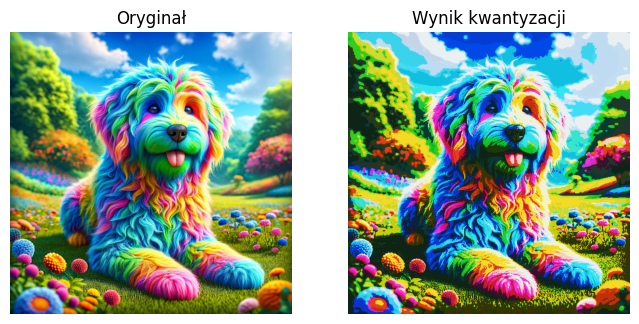

MSE: 1203.8451, max_color_cost: 76.2234, mean_color_cost: 68.4972
Score: 6885.2624
MSE: 1095.8334, max_color_cost: 83.2166, mean_color_cost: 74.7387
Score: 7078.2411
MSE: 1159.4503, max_color_cost: 79.0063, mean_color_cost: 72.3564
Score: 7017.0011
MSE: 1124.3107, max_color_cost: 80.9074, mean_color_cost: 73.8549
Score: 7049.5822
MSE: 1191.4937, max_color_cost: 76.6159, mean_color_cost: 70.8702
Score: 6968.4682
MSE: 1114.6163, max_color_cost: 82.2253, mean_color_cost: 74.6041
Score: 7089.3341
MSE: 1175.8241, max_color_cost: 77.3757, mean_color_cost: 71.3281
Score: 6972.3176
MSE: 2031.0582, max_color_cost: 62.6817, mean_color_cost: 51.7868
Score: 7553.4792
MSE: 730.4826, max_color_cost: 98.1529, mean_color_cost: 88.0961
Score: 7222.2113
MSE: 1809.4259, max_color_cost: 67.8307, mean_color_cost: 57.1795
Score: 7444.8354
MSE: 902.9207, max_color_cost: 111.0225, mean_color_cost: 82.3563
Score: 7596.2780


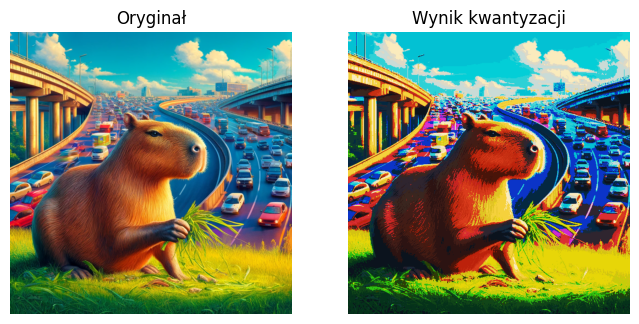

MSE: 1191.4937, max_color_cost: 76.6159, mean_color_cost: 70.8702
Score: 6968.4682
MSE: 818.8174, max_color_cost: 78.0577, mean_color_cost: 60.3015
Score: 5809.5079
MSE: 883.9916, max_color_cost: 61.7414, mean_color_cost: 54.0905
Score: 5336.3557
MSE: 847.6791, max_color_cost: 76.4853, mean_color_cost: 59.1039
Score: 5783.9149
MSE: 934.7657, max_color_cost: 60.8030, mean_color_cost: 52.6767
Score: 5358.8131
MSE: 872.5388, max_color_cost: 76.8049, mean_color_cost: 59.1589
Score: 5842.6544
MSE: 1031.7382, max_color_cost: 65.0077, mean_color_cost: 55.2509
Score: 5749.1751
MSE: 1277.0208, max_color_cost: 65.8179, mean_color_cost: 43.6119
Score: 5767.9199
MSE: 710.3857, max_color_cost: 82.2010, mean_color_cost: 67.8627
Score: 5997.2267
MSE: 1162.2249, max_color_cost: 64.3351, mean_color_cost: 46.1985
Score: 5615.8220
MSE: 821.9277, max_color_cost: 103.9663, mean_color_cost: 61.6337
Score: 6415.7640


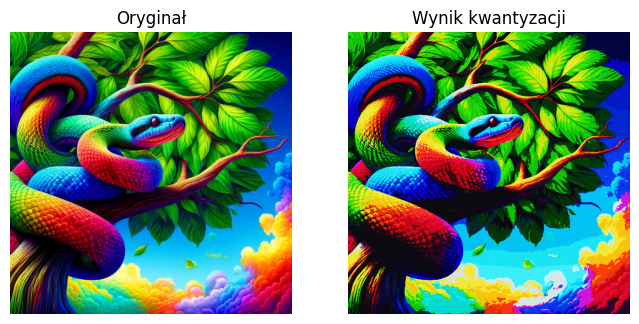

MSE: 883.9916, max_color_cost: 61.7414, mean_color_cost: 54.0905
Score: 5336.3557
MSE: 887.8480, max_color_cost: 81.0555, mean_color_cost: 63.6424
Score: 6150.8424
MSE: 1033.0902, max_color_cost: 71.9583, mean_color_cost: 59.0086
Score: 6055.6659
MSE: 855.2075, max_color_cost: 80.0375, mean_color_cost: 63.5294
Score: 6059.4369
MSE: 1062.9259, max_color_cost: 71.4073, mean_color_cost: 58.5661
Score: 6085.1823
MSE: 934.0781, max_color_cost: 82.5893, mean_color_cost: 63.4867
Score: 6268.9733
MSE: 1086.4392, max_color_cost: 71.7008, mean_color_cost: 58.1604
Score: 6121.3314
MSE: 1565.0822, max_color_cost: 69.0000, mean_color_cost: 45.0877
Score: 6472.8496
MSE: 652.6984, max_color_cost: 91.4221, mean_color_cost: 73.6787
Score: 6319.7672
MSE: 1306.0660, max_color_cost: 67.3869, mean_color_cost: 50.2450
Score: 6137.5484
MSE: 770.6209, max_color_cost: 112.0759, mean_color_cost: 70.0386
Score: 6836.4580


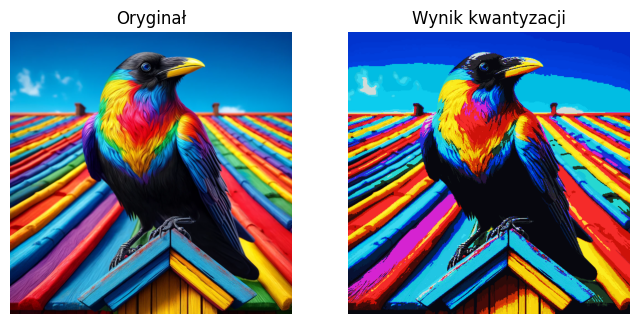

MSE: 1033.0902, max_color_cost: 71.9583, mean_color_cost: 59.0086
Score: 6055.6659
MSE: 1445.2539, max_color_cost: 90.4931, mean_color_cost: 82.0454
Score: 8236.7685
MSE: 1429.6719, max_color_cost: 91.6788, mean_color_cost: 82.4741
Score: 8248.5117
MSE: 1435.9086, max_color_cost: 91.6679, mean_color_cost: 82.2841
Score: 8252.7757
MSE: 1406.6367, max_color_cost: 91.0275, mean_color_cost: 82.4689
Score: 8188.5435
MSE: 1449.7010, max_color_cost: 90.5594, mean_color_cost: 81.9118
Score: 8241.4435
MSE: 1453.0023, max_color_cost: 89.5935, mean_color_cost: 81.4545
Score: 8208.5570
MSE: 3111.7161, max_color_cost: 64.0312, mean_color_cost: 50.5716
Score: 9692.0938
MSE: 835.5432, max_color_cost: 112.6543, mean_color_cost: 99.4227
Score: 8212.5801
MSE: 2262.7898, max_color_cost: 72.6774, mean_color_cost: 64.9164
Score: 8778.2948
MSE: 908.0544, max_color_cost: 114.4159, mean_color_cost: 94.2553
Score: 8177.5649


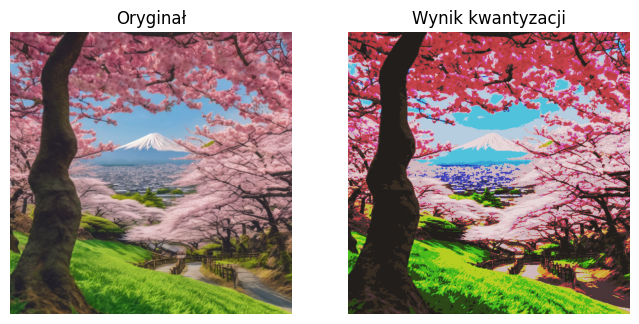

MSE: 908.0544, max_color_cost: 114.4159, mean_color_cost: 94.2553
Score: 8177.5649
Finałowy wynik to: 6684.6634


In [8]:
if not FINAL_EVALUATION_MODE:
    print(f"Finałowy wynik to: {evaluate_algorithm(your_quantization_algorithm, 'valid_data'):.4f}")
